# Unidad 1 · Atributos: carta p con n variable y muestreo de aceptación

**Planta:** Conservas del Itata S.A. — inspección de lotes terminados
**Datos:** `DatosClases/1_Calidad/itata_atributos.csv` (24 lotes inspeccionados)
y `DatosClases/1_Calidad/oc_plan.csv` (curva OC del plan n = 80, c = 2)

---

## Qué se decide aquí

Los tres cuadernos anteriores trabajaron con una **variable**: el peso, un
número en una escala continua. Buena parte de lo que se inspecciona en una
planta de conservas no es así: un envase tiene o no tiene el sello
defectuoso, el rótulo está o no está torcido. Son **atributos**, y cambian
tanto la carta como la matemática que hay detrás: en lugar de la normal, la
binomial.

El cuaderno tiene dos partes, y la relación entre ellas es el argumento
central del día:

* **(a) Carta p.** Vigila la fracción defectuosa lote a lote. Es control de
  proceso: detecta cuándo algo cambió, para ir a buscarlo.
* **(b) Muestreo de aceptación.** Decide si un lote ya fabricado se acepta o
  se rechaza inspeccionando una muestra. Es control de salida: no cambia nada
  del proceso, solo separa.

La conclusión que hay que llevarse es que la segunda no sustituye a la
primera. **La inspección no crea calidad**: solo la descubre, tarde, y de
forma imperfecta. Aceptar un lote no significa que no tenga defectuosas — el
muestreo transfiere riesgo entre productor y cliente, no lo elimina.

## Cifras de referencia

| cantidad | valor |
|---|---|
| p̄ (313 / 7 719) | 0,0405 |
| n por lote | entre 252 y 397 (variable) |
| lote fuera de control | 15 (p = 0,0864 > LCS = 0,0718) |
| causa del lote 15 | Sello defectuoso |
| Pareto: Sello / Peso / Rotulado / Abolladura | 157 / 96 / 56 / 4 |
| LCS con n medio (322) | 0,0735 |
| Pa(1 %) · Pa(2 %) · Pa(3 %) · Pa(5 %) | 0,9534 · 0,7844 · 0,5681 · 0,2306 |
| α con AQL = 1 % | 0,0466 |
| LTPD (Pa = 10 %) | 0,0652 |
| razón de discriminación LTPD/AQL | 6,5 |
| AOQL | 0,0164 en p = 2,81 % |

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

atr = pd.read_csv(datos("1_Calidad", "itata_atributos.csv"))
oc_ref = pd.read_csv(datos("1_Calidad", "oc_plan.csv"))

print(f"{len(atr)} lotes inspeccionados")
print(f"  unidades inspeccionadas: {atr.n_inspeccionadas.sum():,}")
print(f"  unidades defectuosas:    {atr.n_defectuosas.sum():,}")
print(f"  tamaño de muestra por lote: entre {atr.n_inspeccionadas.min()} "
      f"y {atr.n_inspeccionadas.max()}")
atr.head()

24 lotes inspeccionados
  unidades inspeccionadas: 7,719
  unidades defectuosas:    313
  tamaño de muestra por lote: entre 252 y 397


,lote,n_inspeccionadas,n_defectuosas,causa_principal
0,1,260,13,Peso fuera de rango
1,2,296,18,Peso fuera de rango
2,3,319,12,Peso fuera de rango
3,4,318,14,Rotulado
4,5,254,12,Peso fuera de rango


# Parte (a) — Carta p con tamaño de muestra variable

## 1. La línea central: por qué p̄ no es el promedio de las p

La fracción defectuosa de cada lote es pᵢ = xᵢ/nᵢ. La tentación es promediar
esas 24 fracciones. Es incorrecto, y por una razón que no es un tecnicismo:
un lote de 252 unidades y uno de 397 no aportan la misma cantidad de
información sobre la fracción defectuosa del proceso, y promediar las
fracciones les da el mismo peso.

La línea central correcta es la fracción **global**, defectuosas totales sobre
inspeccionadas totales:

$$\bar{p} = \frac{\sum x_i}{\sum n_i}$$

que equivale a un promedio ponderado por nᵢ. La diferencia numérica suele ser
pequeña; el hábito de pensar en qué se está promediando no lo es.

In [2]:
total_def = atr.n_defectuosas.sum()
total_insp = atr.n_inspeccionadas.sum()
pbar = total_def / total_insp

atr["p"] = atr.n_defectuosas / atr.n_inspeccionadas
promedio_ingenuo = atr.p.mean()

print(f"  p-barra = {total_def} / {total_insp:,} = {pbar:.4f}"
      f"   ({100*pbar:.2f} % defectuosas)")
print(f"  (promedio simple de las 24 fracciones = {promedio_ingenuo:.4f}, "
      f"que NO es la línea central)")

  p-barra = 313 / 7,719 = 0.0405   (4.05 % defectuosas)
  (promedio simple de las 24 fracciones = 0.0403, que NO es la línea central)


## 2. Límites que cambian de lote a lote

Aquí está el punto de la primera mitad del cuaderno. La carta p se construye
sobre la binomial: si cada unidad es defectuosa con probabilidad p de forma
independiente, la fracción defectuosa de una muestra de tamaño n tiene
desviación estándar

$$\sigma_p = \sqrt{\frac{p(1-p)}{n}}$$

y los límites son p̄ ± 3σ_p. **El n está en la fórmula.** Si el tamaño de
muestra cambia lote a lote, los límites cambian lote a lote: la carta tiene
forma de escalera, no de pasillo recto.

La razón es intuitiva una vez dicha: con más unidades inspeccionadas se estima
mejor la fracción, así que una desviación menor ya resulta sospechosa. Un
6 % de defectuosas en 260 unidades puede ser azar; el mismo 6 % en 397 casi
seguro no lo es. Un límite constante trataría a los dos igual, y ahí está el
error.

El límite inferior se trunca en cero porque una fracción negativa no existe.
Cuando p̄ es pequeña y n moderado, el LCI sale negativo y la carta pierde la
capacidad de detectar **mejoras** — lo que, dicho sea de paso, es una
limitación real de la carta p, no una curiosidad.

In [3]:
sigma_p = np.sqrt(pbar * (1 - pbar) / atr.n_inspeccionadas)
atr["LCS"] = pbar + 3 * sigma_p
atr["LCI"] = np.maximum(0.0, pbar - 3 * sigma_p)
atr["fuera"] = (atr.p > atr.LCS) | (atr.p < atr.LCI)

print(atr[["lote", "n_inspeccionadas", "n_defectuosas", "p", "LCI", "LCS",
           "fuera"]].to_string(index=False,
                               float_format=lambda v: f"{v:8.4f}"))

fuera = atr[atr.fuera]
print(f"\n  Lotes fuera de control: {list(fuera.lote)}")
for _, r in fuera.iterrows():
    print(f"    Lote {int(r.lote)}: p = {r.p:.4f} > LCS = {r.LCS:.4f} "
          f"(n = {int(r.n_inspeccionadas)})  causa: {r.causa_principal}")

 lote  n_inspeccionadas  n_defectuosas        p      LCI      LCS  fuera
    1               260             13   0.0500   0.0039   0.0772  False
    2               296             18   0.0608   0.0062   0.0749  False
    3               319             12   0.0376   0.0074   0.0737  False
    4               318             14   0.0440   0.0074   0.0737  False
    5               254             12   0.0472   0.0034   0.0777  False
    6               351             12   0.0342   0.0090   0.0721  False
    7               367             10   0.0272   0.0097   0.0714  False
    8               278              5   0.0180   0.0051   0.0760  False
    9               346             14   0.0405   0.0087   0.0724  False
   10               280             12   0.0429   0.0052   0.0759  False
   11               347             11   0.0317   0.0088   0.0723  False
   12               373             23   0.0617   0.0099   0.0712  False
   13               307             12   0.0391   0

## 3. El error de usar un LCS constante

La simplificación tentadora es calcular un solo límite con el n promedio y
dibujar una línea recta. Se ve mejor en la lámina y se explica en un minuto.
Conviene ver exactamente qué se rompe.

In [4]:
n_medio = atr.n_inspeccionadas.mean()
lcs_constante = pbar + 3 * np.sqrt(pbar * (1 - pbar) / n_medio)

atr["fuera_const"] = atr.p > lcs_constante
discrepan = atr[atr.fuera != atr.fuera_const]

print(f"  n medio = {n_medio:.0f}  ->  LCS constante = {lcs_constante:.4f}")
print(f"  LCS variable: entre {atr.LCS.min():.4f} (n = "
      f"{atr.n_inspeccionadas.max()}) y {atr.LCS.max():.4f} "
      f"(n = {atr.n_inspeccionadas.min()})")
print(f"\n  Lotes marcados con límites variables : {list(atr[atr.fuera].lote)}")
print(f"  Lotes marcados con LCS constante     : "
      f"{list(atr[atr.fuera_const].lote)}")
print(f"  Lotes en que las dos cartas discrepan: "
      f"{list(discrepan.lote) if len(discrepan) else 'ninguno'}")

  n medio = 322  ->  LCS constante = 0.0735
  LCS variable: entre 0.0702 (n = 397) y 0.0778 (n = 252)

  Lotes marcados con límites variables : [15]
  Lotes marcados con LCS constante     : [15]
  Lotes en que las dos cartas discrepan: ninguno


En **estos** datos las dos cartas coinciden, y es importante no sacar de ahí
la conclusión equivocada. Que coincidan es una casualidad del conjunto: el n
varía entre 252 y 397, lo que mueve el LCS entre 0,0654 y 0,0780, y ningún
lote cayó en esa banda de ambigüedad salvo el 15, que está muy por encima de
cualquiera de los dos límites.

El error del LCS constante es de **tasa de falsa alarma**, y es estructural,
no accidental:

* en un lote **grande** (n = 397) el LCS verdadero es 0,0654 y el constante
  0,0735: la carta constante es demasiado permisiva y **deja pasar** señales
  reales;
* en un lote **chico** (n = 252) el LCS verdadero es 0,0780 y el constante
  0,0735: la carta constante es demasiado estricta y **genera falsas
  alarmas**.

Una carta cuya probabilidad de falsa alarma cambia según el lote no tiene la
garantía estadística que justifica usarla, que era precisamente el argumento
del cuaderno 1 contra poner los límites a ojo. La regla práctica de la
literatura es que los límites constantes son tolerables si el n de cada lote
no se aparta más de ±25 % del n medio; aquí el rango va de −22 % a +23 %,
justo en el borde, lo que explica que los resultados coincidan por poco.

La alternativa correcta cuando se necesita una línea recta es la **carta
estandarizada**: se grafica zᵢ = (pᵢ − p̄)/σ_pᵢ, cuyos límites son ±3 fijos por
construcción. Se pierde la escala física, se gana la garantía.

In [5]:
atr["z"] = (atr.p - pbar) / np.sqrt(pbar * (1 - pbar) / atr.n_inspeccionadas)
print("  Carta estandarizada (límites fijos en ±3):")
print(atr[["lote", "n_inspeccionadas", "p", "z"]]
      .to_string(index=False, float_format=lambda v: f"{v:8.3f}"))
print(f"\n  Lotes con |z| > 3: "
      f"{list(atr[atr.z.abs() > 3].lote)}  (mismo diagnóstico, escala distinta)")

  Carta estandarizada (límites fijos en ±3):
 lote  n_inspeccionadas        p        z
    1               260    0.050    0.773
    2               296    0.061    1.767
    3               319    0.038   -0.265
    4               318    0.044    0.314
    5               254    0.047    0.541
    6               351    0.034   -0.604
    7               367    0.027   -1.292
    8               278    0.018   -1.907
    9               346    0.040   -0.008
   10               280    0.043    0.196
   11               347    0.032   -0.836
   12               373    0.062    2.067
   13               307    0.039   -0.130
   14               264    0.038   -0.220
   15               359    0.086    4.400
   16               397    0.038   -0.279
   17               346    0.012   -2.734
   18               384    0.055    1.405
   19               252    0.032   -0.709
   20               316    0.035   -0.517
   21               288    0.028   -1.099
   22               347    0.03

## 4. Pareto: qué causa perseguir primero

La carta dice *cuándo* pasó algo. El Pareto dice *qué* perseguir. Son
complementarios y el orden natural es: la carta detecta el lote 15, el Pareto
muestra que el problema dominante de toda la serie es el mismo que produjo
ese lote.

El principio de Pareto —pocas causas explican la mayoría de los defectos— no
es una ley de la naturaleza, es una regularidad empírica lo bastante robusta
como para organizar el trabajo. Su valor está en lo que impide: repartir el
esfuerzo de mejora en partes iguales entre cuatro causas que no pesan lo
mismo.

In [6]:
pareto = (atr.groupby("causa_principal")["n_defectuosas"].sum()
             .sort_values(ascending=False).reset_index())
pareto["pct"] = 100 * pareto.n_defectuosas / pareto.n_defectuosas.sum()
pareto["pct_acum"] = pareto.pct.cumsum()

print(pareto.to_string(index=False, float_format=lambda v: f"{v:7.1f}"))
print(f"\n  Las 2 primeras causas explican "
      f"{pareto.pct_acum.iloc[1]:.1f} % de las unidades defectuosas.")
print(f"  'Sello defectuoso' es además la causa del único lote fuera de"
      f" control.")

    causa_principal  n_defectuosas     pct  pct_acum
   Sello defectuoso            157    50.2      50.2
Peso fuera de rango             96    30.7      80.8
           Rotulado             56    17.9      98.7
         Abolladura              4     1.3     100.0

  Las 2 primeras causas explican 80.8 % de las unidades defectuosas.
  'Sello defectuoso' es además la causa del único lote fuera de control.


## 5. Los dos gráficos de la parte (a)

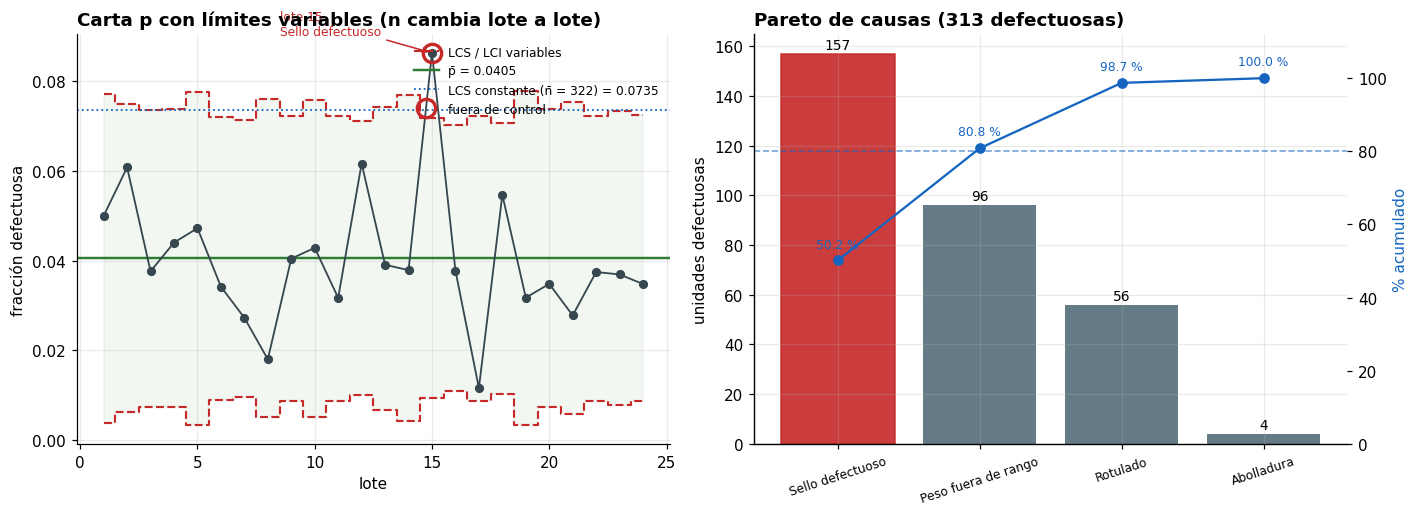

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

# --- carta p con límites escalonados
a = ax[0]
a.step(atr.lote, atr.LCS, where="mid", color="#c62828", lw=1.4, ls="--",
       label="LCS / LCI variables")
a.step(atr.lote, atr.LCI, where="mid", color="#c62828", lw=1.4, ls="--")
a.fill_between(atr.lote, atr.LCI, atr.LCS, step="mid", color="#2e7d32",
               alpha=0.06)
a.axhline(pbar, color="#2e7d32", lw=1.6, label=f"p̄ = {pbar:.4f}")
a.axhline(lcs_constante, color="#1565c0", lw=1.2, ls=":",
          label=f"LCS constante (n̄ = {n_medio:.0f}) = {lcs_constante:.4f}")
a.plot(atr.lote, atr.p, "o-", color="#37474f", ms=5, lw=1.2, zorder=3)
a.plot(fuera.lote, fuera.p, "o", color="#c62828", ms=12, mfc="none", mew=2.2,
       zorder=4, label="fuera de control")
for _, r in fuera.iterrows():
    a.annotate(f"lote {int(r.lote)}\n{r.causa_principal}",
               xy=(r.lote, r.p), xytext=(r.lote - 6.5, r.p + 0.004),
               fontsize=8, color="#c62828",
               arrowprops=dict(arrowstyle="->", color="#c62828"))
a.set_xlabel("lote")
a.set_ylabel("fracción defectuosa")
a.set_title("Carta p con límites variables (n cambia lote a lote)", loc="left")
a.legend(fontsize=8, loc="upper right")

# --- Pareto
b = ax[1]
barras = b.bar(pareto.causa_principal, pareto.n_defectuosas, color="#546e7a",
               alpha=0.9)
barras[0].set_color("#c62828")
for r, v in zip(barras, pareto.n_defectuosas):
    b.text(r.get_x() + r.get_width() / 2, v + 2, str(int(v)), ha="center",
           fontsize=9)
b2 = b.twinx()
b2.plot(pareto.causa_principal, pareto.pct_acum, "o-", color="#1565c0", ms=6)
for x, y in zip(pareto.causa_principal, pareto.pct_acum):
    b2.text(x, y + 3.5, f"{y:.1f} %", ha="center", fontsize=8, color="#1565c0")
b2.axhline(80, color="#1565c0", ls="--", lw=1.1, alpha=0.6)
b2.set_ylim(0, 112)
b2.set_ylabel("% acumulado", color="#1565c0")
b2.grid(False)
b.set_ylabel("unidades defectuosas")
b.set_title(f"Pareto de causas ({int(pareto.n_defectuosas.sum())} defectuosas)",
            loc="left")
b.tick_params(axis="x", labelrotation=18, labelsize=8)

figura(fig, "carta_p_pareto")
plt.show()

La escalera roja es la carta p correcta: los límites se aprietan cuando se
inspeccionan más unidades. La línea azul punteada es la simplificación que
aquí no cambia el resultado y que en otro conjunto sí lo haría.

---

# Parte (b) — Muestreo de aceptación

## 6. El plan, y lo que un plan puede y no puede hacer

Hasta aquí se vigiló el proceso. Ahora la pregunta es otra: llega un lote de
N = 2 000 envases y hay que decidir si se acepta. Inspeccionarlo completo es
caro, lento y —cuando la inspección es destructiva, como pesar el escurrido—
imposible. Un **plan de muestreo simple** dice: inspeccione n = 80 unidades,
acepte el lote si encuentra c = 2 defectuosas o menos, recháncelo si encuentra
más.

Antes de calcular nada conviene fijar la idea que todo el resto desarrolla:
**aceptar un lote no significa que el lote esté bien**. Significa que en 80
unidades aparecieron 2 o menos defectuosas, lo que es compatible con muchas
calidades distintas del lote. El plan no mejora el lote ni lo garantiza:
reparte de una manera determinada el riesgo de equivocarse entre el productor
y el cliente. Elegir un plan es elegir ese reparto.

In [8]:
LOTE_N, PLAN_n, PLAN_c = 2000, 80, 2

print(f"  Lote N = {LOTE_N}   plan simple: n = {PLAN_n}, c = {PLAN_c}")
print(f"  Se inspecciona el {100*PLAN_n/LOTE_N:.0f} % del lote.")
print(f"\n  Con la fracción defectuosa de la planta (p̄ = {pbar:.4f}):")
pa_planta = stats.binom.cdf(PLAN_c, PLAN_n, pbar)
print(f"    Pa = P(X <= {PLAN_c} | n = {PLAN_n}, p = {pbar:.4f}) "
      f"= {pa_planta:.4f}")
print(f"    es decir, {100*(1-pa_planta):.1f} % de los lotes de la planta"
      f" serían rechazados.")

  Lote N = 2000   plan simple: n = 80, c = 2
  Se inspecciona el 4 % del lote.

  Con la fracción defectuosa de la planta (p̄ = 0.0405):
    Pa = P(X <= 2 | n = 80, p = 0.0405) = 0.3655
    es decir, 63.4 % de los lotes de la planta serían rechazados.


## 7. La curva OC

La **curva característica de operación** es el plan entero en un gráfico: para
cada fracción defectuosa real p del lote, la probabilidad de aceptarlo.

$$P_a(p) = P(X \le c) = \sum_{x=0}^{c} \binom{n}{x} p^x (1-p)^{n-x}$$

Lo que hay que mirar en la curva no es dónde empieza ni dónde termina, sino
**qué tan rápido baja**. Un plan ideal sería un escalón: aceptar todo lo bueno
y rechazar todo lo malo. Ningún plan real lo es, y la pendiente de la curva
mide cuánta ambigüedad queda.

In [9]:
p_grid = np.arange(0.0, 0.1001, 0.0025)
oc = pd.DataFrame({
    "p": p_grid,
    "Pa_binomial": stats.binom.cdf(PLAN_c, PLAN_n, p_grid),
    "Pa_hipergeometrica": [
        stats.hypergeom.cdf(PLAN_c, LOTE_N, int(round(p * LOTE_N)), PLAN_n)
        for p in p_grid],
})

puntos = pd.DataFrame({"p": [0.01, 0.02, 0.03, 0.05]})
puntos["Pa"] = stats.binom.cdf(PLAN_c, PLAN_n, puntos.p)
puntos["riesgo_rechazo"] = 1 - puntos.Pa

print(puntos.to_string(index=False, float_format=lambda v: f"{v:9.4f}"))
print(f"\n  Léase la primera fila con cuidado: un lote con 1 % de defectuosas"
      f"\n  -- que es buena calidad -- se rechaza igual "
      f"{100*puntos.riesgo_rechazo.iloc[0]:.1f} % de las veces.")
print(f"  Y un lote con 5 % se ACEPTA "
      f"{100*puntos.Pa.iloc[3]:.1f} % de las veces.")

        p        Pa  riesgo_rechazo
   0.0100    0.9534          0.0466
   0.0200    0.7844          0.2156
   0.0300    0.5681          0.4319
   0.0500    0.2306          0.7694

  Léase la primera fila con cuidado: un lote con 1 % de defectuosas
  -- que es buena calidad -- se rechaza igual 4.7 % de las veces.
  Y un lote con 5 % se ACEPTA 23.1 % de las veces.


## 8. Binomial o hipergeométrica: cuál corresponde y cuándo da igual

La distribución exacta del número de defectuosas en la muestra es
**hipergeométrica**: se extraen 80 unidades *sin reemplazo* de un lote finito
de 2 000 que contiene D defectuosas. Cada extracción cambia la composición de
lo que queda.

La binomial supone extracciones independientes con p constante, lo que sería
exacto solo con reemplazo o con un lote infinito. Es una aproximación, y es la
que usa toda la literatura de muestreo por una razón práctica: la binomial no
necesita conocer N, así que el mismo plan sirve para lotes de cualquier
tamaño.

La regla habitual es que la aproximación es buena cuando n/N ≤ 0,10. Aquí
n/N = 0,04, cómodamente dentro. El archivo `oc_plan.csv` trae las dos curvas
calculadas y permite verificar que la regla funciona en lugar de creerla.

In [10]:
comp = oc.merge(oc_ref, on="p", suffixes=("_calc", "_ref"))
comp["dif"] = (comp.Pa_binomial_calc - comp.Pa_hipergeometrica_calc).abs()

print(f"  n/N = {PLAN_n}/{LOTE_N} = {PLAN_n/LOTE_N:.2f}"
      f"   (regla práctica: aproximación válida si <= 0.10)")
print(f"\n  Diferencia máxima |Pa_bin - Pa_hip| = {comp.dif.max():.4f} "
      f"en p = {comp.loc[comp.dif.idxmax(), 'p']:.4f}")
print(f"  Diferencia media                    = {comp.dif.mean():.4f}")
print(f"\n  Comparación con el archivo de referencia oc_plan.csv:")
print(f"    máx |calculado - referencia| binomial       = "
      f"{(comp.Pa_binomial_calc - comp.Pa_binomial_ref).abs().max():.5f}")
print(f"    máx |calculado - referencia| hipergeométrica= "
      f"{(comp.Pa_hipergeometrica_calc - comp.Pa_hipergeometrica_ref).abs().max():.5f}")
print(f"\n  (La referencia está redondeada a 4 decimales; la coincidencia"
      f"\n   confirma que la aritmética es la misma.)")

  n/N = 80/2000 = 0.04   (regla práctica: aproximación válida si <= 0.10)

  Diferencia máxima |Pa_bin - Pa_hip| = 0.0059 en p = 0.0500
  Diferencia media                    = 0.0032

  Comparación con el archivo de referencia oc_plan.csv:
    máx |calculado - referencia| binomial       = 0.00005
    máx |calculado - referencia| hipergeométrica= 0.00005

  (La referencia está redondeada a 4 decimales; la coincidencia
   confirma que la aritmética es la misma.)


La diferencia máxima es de milésimas. La hipergeométrica es *ligeramente* más
optimista en la zona intermedia, porque el muestreo sin reemplazo tiene menos
varianza. Para efectos de decisión, con n/N = 0,04, da lo mismo — y conviene
decir explícitamente que eso **deja de ser cierto** con lotes chicos: con
N = 200 y n = 80 la diferencia sería grande y usar la binomial sería un error.

## 9. Los cuatro números que definen un plan

Un plan se describe con cuatro cifras, y cada una es un compromiso negociado
entre productor y cliente, no un parámetro técnico:

* **AQL** (*acceptable quality level*): la calidad que se considera buena y
  que el plan debería aceptar casi siempre. Aquí se fija en 1 %.
* **α** (riesgo del productor) = 1 − Pa(AQL): la probabilidad de rechazar un
  lote bueno. Es el costo de los falsos rechazos, y lo paga el que fabrica.
* **LTPD** (*lot tolerance percent defective*): la calidad que se considera
  mala. Convencionalmente se define como el p en que Pa = 10 %.
* **β** (riesgo del consumidor) = Pa(LTPD) = 0,10 por definición: la
  probabilidad de aceptar un lote malo. Lo paga el que compra.

La **razón de discriminación** LTPD/AQL resume la calidad del plan: cuán
separadas tienen que estar «bueno» y «malo» para que el plan los distinga con
confianza. Más chica es mejor. La única forma de reducirla es aumentar n.

In [11]:
AQL = 0.01
pa_aql = stats.binom.cdf(PLAN_c, PLAN_n, AQL)
alpha = 1 - pa_aql

ps = np.arange(0.001, 0.15, 0.0001)
pas = stats.binom.cdf(PLAN_c, PLAN_n, ps)
ltpd = ps[np.argmin(np.abs(pas - 0.10))]
razon = ltpd / AQL

print(f"  AQL  = {AQL:.0%}   Pa = {pa_aql:.4f}   "
      f"alpha (riesgo del productor) = {alpha:.4f}")
print(f"  LTPD = {ltpd:.4f} ({ltpd:.2%})   Pa = "
      f"{stats.binom.cdf(PLAN_c, PLAN_n, ltpd):.4f}   "
      f"beta (riesgo del consumidor) = 0.10")
print(f"\n  Razón de discriminación = LTPD / AQL = {ltpd:.4f} / {AQL:.2f} "
      f"= {razon:.1f}")
print(f"\n  Traducción: el plan distingue con seguridad un lote al 1 % de uno"
      f"\n  al 6,5 %. Todo lo que hay en medio lo decide, en buena parte, el"
      f"\n  azar de qué 80 envases salieron.")

  AQL  = 1%   Pa = 0.9534   alpha (riesgo del productor) = 0.0466
  LTPD = 0.0652 (6.52%)   Pa = 0.0998   beta (riesgo del consumidor) = 0.10

  Razón de discriminación = LTPD / AQL = 0.0652 / 0.01 = 6.5

  Traducción: el plan distingue con seguridad un lote al 1 % de uno
  al 6,5 %. Todo lo que hay en medio lo decide, en buena parte, el
  azar de qué 80 envases salieron.


## 10. AOQ y AOQL: la calidad que realmente sale

Falta una pieza. En un esquema de inspección rectificadora, los lotes
rechazados se inspeccionan al 100 % y se reemplazan las defectuosas
encontradas. ¿Cuál es entonces la calidad promedio de lo que efectivamente
llega al cliente?

Si el lote se acepta (probabilidad Pa) queda con su fracción p, salvo las n
unidades ya inspeccionadas que están limpias. Si se rechaza, queda perfecto.
Promediando:

$$AOQ(p) = p \cdot P_a(p) \cdot \frac{N-n}{N}$$

La forma de esta curva es la parte interesante. En p pequeño, el AOQ es
pequeño porque el lote es bueno. En p grande, el AOQ también es pequeño
porque casi todo se rechaza y se rectifica. En el **medio** hay un máximo: el
**AOQL**, la peor calidad promedio que el esquema puede dejar salir, y por lo
tanto una garantía dura hacia el cliente, independiente de cómo se comporte
el proveedor.

In [12]:
aoq = ps * pas * (LOTE_N - PLAN_n) / LOTE_N
i_max = int(np.argmax(aoq))
aoql, p_aoql = aoq[i_max], ps[i_max]

print(f"  AOQL = {aoql:.4f} ({aoql:.2%})  en p = {p_aoql:.4f} ({p_aoql:.2%})")
print(f"\n  Es decir: pase lo que pase con el proveedor, este esquema no deja")
print(f"  salir, en promedio, más de {aoql:.2%} de defectuosas.")
print(f"  El peor caso NO ocurre cuando el proveedor es pésimo, sino cuando es")
print(f"  mediocre ({p_aoql:.2%}): lo bastante malo para colar defectuosas,")
print(f"  lo bastante bueno para que el plan no lo rechace.")

  AOQL = 0.0164 (1.64%)  en p = 0.0281 (2.81%)

  Es decir: pase lo que pase con el proveedor, este esquema no deja
  salir, en promedio, más de 1.64% de defectuosas.
  El peor caso NO ocurre cuando el proveedor es pésimo, sino cuando es
  mediocre (2.81%): lo bastante malo para colar defectuosas,
  lo bastante bueno para que el plan no lo rechace.


## 11. Los dos gráficos de la parte (b)

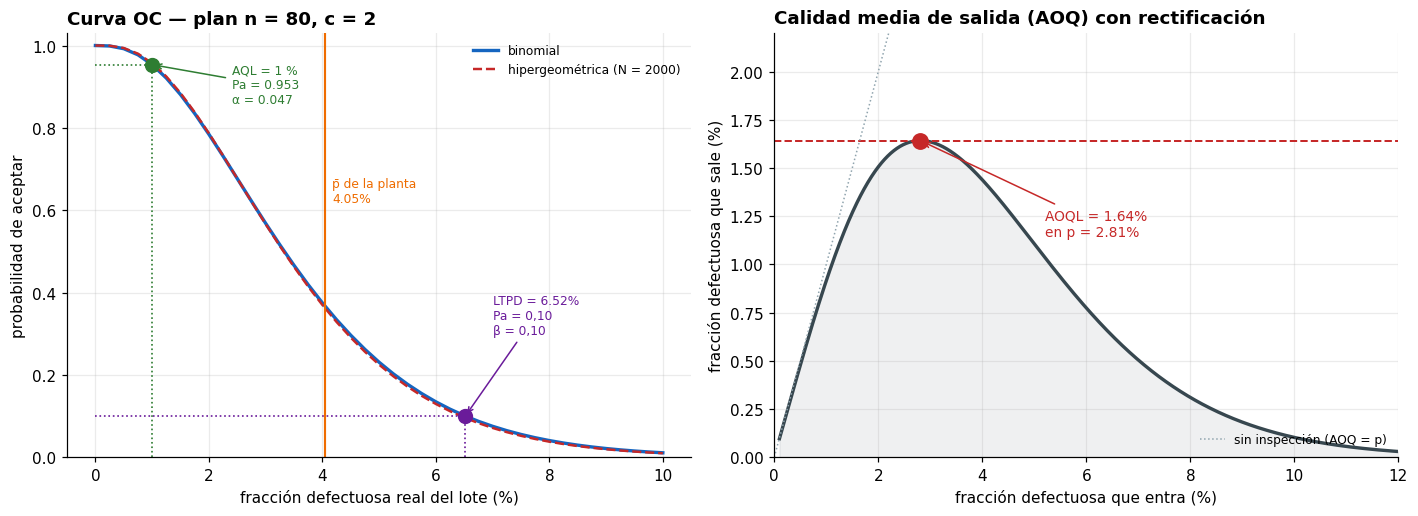

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

# --- curva OC
a = ax[0]
a.plot(oc.p * 100, oc.Pa_binomial, color="#1565c0", lw=2.2, label="binomial")
a.plot(oc.p * 100, oc.Pa_hipergeometrica, color="#c62828", lw=1.6, ls="--",
       label=f"hipergeométrica (N = {LOTE_N})")
a.plot([0, AQL * 100], [pa_aql, pa_aql], color="#2e7d32", lw=1.1, ls=":")
a.plot([AQL * 100, AQL * 100], [0, pa_aql], color="#2e7d32", lw=1.1, ls=":")
a.plot([0, ltpd * 100], [0.10, 0.10], color="#6a1b9a", lw=1.1, ls=":")
a.plot([ltpd * 100, ltpd * 100], [0, 0.10], color="#6a1b9a", lw=1.1, ls=":")
a.plot(AQL * 100, pa_aql, "o", color="#2e7d32", ms=9, zorder=5)
a.plot(ltpd * 100, 0.10, "o", color="#6a1b9a", ms=9, zorder=5)
a.annotate(f"AQL = 1 %\nPa = {pa_aql:.3f}\nα = {alpha:.3f}",
           xy=(AQL * 100, pa_aql), xytext=(2.4, 0.86), fontsize=8,
           color="#2e7d32",
           arrowprops=dict(arrowstyle="->", color="#2e7d32"))
a.annotate(f"LTPD = {ltpd:.2%}\nPa = 0,10\nβ = 0,10",
           xy=(ltpd * 100, 0.10), xytext=(7.0, 0.30), fontsize=8,
           color="#6a1b9a",
           arrowprops=dict(arrowstyle="->", color="#6a1b9a"))
a.axvline(pbar * 100, color="#ef6c00", lw=1.4)
a.text(pbar * 100 + 0.12, 0.62, f"p̄ de la planta\n{pbar:.2%}", fontsize=8,
       color="#ef6c00")
a.set_xlabel("fracción defectuosa real del lote (%)")
a.set_ylabel("probabilidad de aceptar")
a.set_ylim(0, 1.03)
a.set_title(f"Curva OC — plan n = {PLAN_n}, c = {PLAN_c}", loc="left")
a.legend(fontsize=8, loc="upper right")

# --- AOQ
b = ax[1]
b.plot(ps * 100, aoq * 100, color="#37474f", lw=2.2)
b.fill_between(ps * 100, 0, aoq * 100, color="#37474f", alpha=0.08)
b.axhline(aoql * 100, color="#c62828", lw=1.3, ls="--")
b.plot(p_aoql * 100, aoql * 100, "o", color="#c62828", ms=10, zorder=5)
b.annotate(f"AOQL = {aoql:.2%}\nen p = {p_aoql:.2%}",
           xy=(p_aoql * 100, aoql * 100), xytext=(5.2, 1.15), fontsize=9,
           color="#c62828",
           arrowprops=dict(arrowstyle="->", color="#c62828"))
b.plot([0, 100 * ps.max()], [0, 100 * ps.max()], color="#90a4ae", lw=1.0,
       ls=":", label="sin inspección (AOQ = p)")
b.set_xlim(0, 12)
b.set_ylim(0, 2.2)
b.set_xlabel("fracción defectuosa que entra (%)")
b.set_ylabel("fracción defectuosa que sale (%)")
b.set_title("Calidad media de salida (AOQ) con rectificación", loc="left")
b.legend(fontsize=8, loc="lower right")

figura(fig, "curva_oc_aoq")
plt.show()

La curva OC es el gráfico que resume el argumento del cuaderno. No es un
escalón: es una rampa larga. Entre 1 % y 6,5 % de defectuosas el plan responde
con probabilidades intermedias, es decir, **no sabe**. La línea naranja marca
dónde opera la planta: con p̄ = 4,05 %, este plan rechazaría cerca de dos de
cada tres lotes. Eso no es un plan mal diseñado; es un proceso que no está a
la altura del plan, y la respuesta correcta no es aflojar el c sino atacar el
sello defectuoso que el Pareto ya identificó.

## 12. Comprobación contra las cifras de referencia

In [14]:
print("Comprobación:")
ok = [
    verificar(pbar, 0.0405, "p-barra", tol=1e-2),
    verificar(total_def, 313, "total de defectuosas"),
    verificar(total_insp, 7719, "total de inspeccionadas"),
    verificar(float(fuera.p.iloc[0]), 0.0864, "p del lote 15", tol=1e-2),
    verificar(float(fuera.LCS.iloc[0]), 0.0718, "LCS del lote 15", tol=1e-2),
    verificar(lcs_constante, 0.0735, "LCS con n medio", tol=1e-2),
    verificar(int(pareto.n_defectuosas.iloc[0]), 157, "Pareto: Sello defectuoso"),
    verificar(int(pareto.n_defectuosas.iloc[1]), 96, "Pareto: Peso fuera de rango"),
    verificar(int(pareto.n_defectuosas.iloc[2]), 56, "Pareto: Rotulado"),
    verificar(int(pareto.n_defectuosas.iloc[3]), 4, "Pareto: Abolladura"),
    verificar(float(pareto.pct_acum.iloc[0]), 50.2, "Pareto acum. 1ª causa", tol=1e-2),
    verificar(float(pareto.pct_acum.iloc[1]), 80.8, "Pareto acum. 2ª causa", tol=1e-2),
    verificar(float(puntos.Pa.iloc[0]), 0.9534, "Pa(p = 1 %)"),
    verificar(float(puntos.Pa.iloc[1]), 0.7844, "Pa(p = 2 %)"),
    verificar(float(puntos.Pa.iloc[2]), 0.5681, "Pa(p = 3 %)"),
    verificar(float(puntos.Pa.iloc[3]), 0.2306, "Pa(p = 5 %)"),
    verificar(alpha, 0.0466, "alpha con AQL = 1 %", tol=1e-2),
    verificar(ltpd, 0.0652, "LTPD (Pa = 10 %)", tol=1e-2),
    verificar(razon, 6.5, "razón de discriminación", tol=1e-2),
    verificar(aoql, 0.0164, "AOQL", tol=1e-2),
    verificar(p_aoql, 0.0281, "p en que se alcanza el AOQL", tol=1e-2),
]
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")
assert all(ok), "alguna comprobación no reprodujo la cifra de referencia"
assert list(fuera.lote) == [15], f"se esperaba solo el lote 15, salió {list(fuera.lote)}"

tabla(atr, "carta_p_lotes")
tabla(pareto, "pareto_causas")
tabla(oc, "curva_oc")
resumen({"p_barra": pbar, "total_defectuosas": int(total_def),
         "total_inspeccionadas": int(total_insp),
         "n_min": int(atr.n_inspeccionadas.min()),
         "n_max": int(atr.n_inspeccionadas.max()),
         "n_medio": n_medio, "LCS_constante": lcs_constante,
         "lotes_fuera": [int(x) for x in fuera.lote],
         "causa_lote_fuera": list(fuera.causa_principal),
         "pareto": pareto.set_index("causa_principal").n_defectuosas.to_dict(),
         "plan": {"N": LOTE_N, "n": PLAN_n, "c": PLAN_c},
         "Pa_1pct": float(puntos.Pa.iloc[0]), "Pa_2pct": float(puntos.Pa.iloc[1]),
         "Pa_3pct": float(puntos.Pa.iloc[2]), "Pa_5pct": float(puntos.Pa.iloc[3]),
         "AQL": AQL, "alpha": alpha, "LTPD": float(ltpd), "beta": 0.10,
         "razon_discriminacion": float(razon),
         "AOQL": float(aoql), "p_AOQL": float(p_aoql)},
        "resumen_atributos")
print("\nGuardado en resultados/")

Comprobación:
  [  OK  ] p-barra: obtenido 0.0405 | referencia 0.0405 | dif. relativa 4.93e-05
  [  OK  ] total de defectuosas: obtenido 313.0000 | referencia 313.0000 | dif. relativa 0.00e+00
  [  OK  ] total de inspeccionadas: obtenido 7,719.0000 | referencia 7,719.0000 | dif. relativa 0.00e+00
  [  OK  ] p del lote 15: obtenido 0.0864 | referencia 0.0864 | dif. relativa 4.90e-05
  [  OK  ] LCS del lote 15: obtenido 0.0718 | referencia 0.0718 | dif. relativa 2.03e-05
  [  OK  ] LCS con n medio: obtenido 0.0735 | referencia 0.0735 | dif. relativa 4.44e-05
  [  OK  ] Pareto: Sello defectuoso: obtenido 157.0000 | referencia 157.0000 | dif. relativa 0.00e+00
  [  OK  ] Pareto: Peso fuera de rango: obtenido 96.0000 | referencia 96.0000 | dif. relativa 0.00e+00
  [  OK  ] Pareto: Rotulado: obtenido 56.0000 | referencia 56.0000 | dif. relativa 0.00e+00
  [  OK  ] Pareto: Abolladura: obtenido 4.0000 | referencia 4.0000 | dif. relativa 0.00e+00
  [  OK  ] Pareto acum. 1ª causa: obtenido 50.15

---

## Para llevarse

1. **Si n varía, los límites varían.** El tamaño de muestra está dentro de
   √(p̄(1−p̄)/n). Un LCS constante deja pasar señales en los lotes grandes y
   genera falsas alarmas en los chicos, y con ello pierde la garantía
   estadística que justificaba usar la carta. Si hace falta una línea recta,
   la respuesta es la carta estandarizada, no el n promedio.
2. **La carta dice cuándo; el Pareto dice qué.** El lote 15 se disparó por
   sello defectuoso, y el sello defectuoso es además el 50 % de todas las
   defectuosas de la serie. Las dos herramientas apuntan al mismo lugar y esa
   coincidencia es el hallazgo accionable.
3. **Aceptar un lote no significa que no tenga defectuosas.** Con este plan,
   un lote al 5 % se acepta el 23 % de las veces y uno al 1 % se rechaza el
   4,7 %. La razón de discriminación de 6,5 dice hasta dónde llega la
   ambigüedad: entre 1 % y 6,5 % el plan esencialmente no distingue.
4. **La inspección no crea calidad.** El muestreo reparte riesgo entre
   productor y cliente; no cambia lo que el proceso produjo. Con p̄ = 4,05 %
   este plan rechazaría dos de cada tres lotes: la salida no es relajar el
   plan, es arreglar el sello.

## Ejercicios

1. Suponga que el lote 15 se investiga, se encuentra la causa asignable
   (una mordaza de sellado desgastada) y se documenta. Excluya ese lote,
   recalcule p̄ y los límites variables, y vuelva a marcar los fuera de
   control. ¿Aparece algún lote nuevo? ¿Por qué podría aparecer uno que antes
   estaba dentro?
2. La planta quiere un plan con α ≤ 5 % para AQL = 1 % **y** β ≤ 10 % para
   LTPD = 4 %. Busque por prueba y error, sobre la binomial, la pareja (n, c)
   más pequeña que cumpla las dos condiciones. Compárela con n = 80, c = 2 en
   términos de costo de inspección y de razón de discriminación.
3. Recalcule la curva OC y el AOQL para un lote de N = 200 con el mismo plan
   n = 80, c = 2, usando la hipergeométrica y la binomial. ¿Sigue siendo
   aceptable la aproximación binomial? Cuantifique la diferencia máxima entre
   ambas curvas y explique en qué dirección se equivoca quien usa la binomial
   con un lote chico.